# ﾎﾞｰﾙﾄﾞｼﾞｪﾙ SoV Analysis — Equal 1-Week Windows

**Purpose:** Track Share of Voice (SoV) change for ﾎﾞｰﾙﾄﾞｼﾞｪﾙ across three equal-length periods (1 week each) to evaluate the Feb 2026 price discount effect vs clean non-promo baselines.

**Definition:** SoV = Sub-brands purchased during the pre-period by shoppers who bought ﾎﾞｰﾙﾄﾞｼﾞｪﾙ in the target (post) period.

**Period design rationale:**
- All post windows are **exactly 7 days** → buyer counts are directly comparable
- Oct/Nov bottle (ﾎﾞﾄﾙ) strong discount period is **excluded from all post windows**
- Pre-period = 2 months immediately before each post_start

| Period | Post Window (7 days) | Pre Window (2M) | Rationale |
|---|---|---|---|
| Current | 2026-02-09 → 2026-02-15 | 2025-12-09 → 2026-02-08 | First full week of Feb discount; latest complete data |
| Pre-Discount | 2026-02-02 → 2026-02-08 | 2025-12-02 → 2026-02-01 | Week right before promo; same winter season, no discount |
| Baseline | 2026-01-05 → 2026-01-11 | 2025-11-05 → 2026-01-04 | Clean Jan week; no Feb promo (note: pre-period includes Nov tail) |

**Target brand:** ﾎﾞｰﾙﾄﾞｼﾞｪﾙ (`jp_sub_brand_alter_lang_name`)
**Competitor scope:** 洗濯洗剤 sub-category
**Created:** 2026-02-19

---
## 0. Imports & Connection Setup

In [1]:
import os
import pandas as pd
import warnings
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import numpy as np
from dotenv import load_dotenv
import databricks.sql as sql

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')

# ── Japanese font setup (fix 文字化け) ────────────────────────────────────
def _find_japanese_font() -> str | None:
    """Return the first available Japanese-capable font name, or None."""
    candidates = [
        'MS Gothic', 'MS PGothic', 'Yu Gothic', 'Meiryo',
        'IPAexGothic', 'IPAGothic', 'Noto Sans CJK JP',
        'Hiragino Sans', 'Hiragino Kaku Gothic Pro',
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    return None

_jp_font = _find_japanese_font()
if _jp_font:
    plt.rcParams['font.family'] = _jp_font
    print(f'✅ Japanese font set: {_jp_font}')
else:
    print('⚠️  No Japanese font found — labels may show □. '
          'Install MS Gothic / IPAexGothic / Noto Sans CJK JP')

# Load Databricks credentials from .env
load_dotenv(dotenv_path='../../.env')
DATABRICKS_HOST      = os.getenv('DATABRICKS_HOST')
DATABRICKS_TOKEN     = os.getenv('DATABRICKS_TOKEN')
DATABRICKS_HTTP_PATH = os.getenv('DATABRICKS_HTTP_PATH')

assert DATABRICKS_HOST,      'DATABRICKS_HOST not set in .env'
assert DATABRICKS_TOKEN,     'DATABRICKS_TOKEN not set in .env'
assert DATABRICKS_HTTP_PATH, 'DATABRICKS_HTTP_PATH not set in .env'
print('✅ Credentials loaded successfully')

# ── Reusable query helper ──────────────────────────────────────────────────
def execute_query(query: str) -> pd.DataFrame:
    """Execute a SQL query against Databricks and return a DataFrame."""
    with sql.connect(
        server_hostname=DATABRICKS_HOST,
        http_path=DATABRICKS_HTTP_PATH,
        access_token=DATABRICKS_TOKEN
    ) as connection:
        with connection.cursor() as cursor:
            cursor.execute(query)
            result  = cursor.fetchall()
            columns = [desc[0] for desc in cursor.description]
            return pd.DataFrame(result, columns=columns)


✅ Japanese font set: MS Gothic
✅ Credentials loaded successfully


---
## 1. Analysis Parameters

In [2]:
# ── Target definition ─────────────────────────────────────────────────────
TARGET_SUB_BRAND       = 'ﾎﾞｰﾙﾄﾞｼﾞｪﾙ'
SUB_CATEGORY_FILTER    = '洗濯洗剤'
SOV_GRANULARITY_1      = 'jp_brand_alter_lang_name'
SOV_GRANULARITY_2      = 'jp_sub_brand_alter_lang_name'

# ── Period windows ─────────────────────────────────────────────────────────
# All post windows = exactly 7 days (apple-to-apple comparison)
# Pre-period      = 2 months immediately before each post_start
#
# Discount context:
#   Current      : Feb 9-15 = first full week of ﾎﾞｰﾙﾄﾞｼﾞｪﾙ Feb price discount
#   Pre-Discount : Feb 2-8  = week right before the discount; same season
#   Baseline     : Jan 5-11 = clean non-promo Jan week
#                  ⚠️ Baseline pre-period (Nov 5 – Jan 4) includes Nov tail of
#                     ﾎﾞﾄﾙ bottle strong discount → may slightly inflate bottle
#                     brands' SoV in Baseline. Keep this in mind when comparing.
PERIODS = {
    'Current': {
        'post_start': '2026-02-09',
        'post_end':   '2026-02-15',
        'pre_start':  '2025-12-09',
        'pre_end':    '2026-02-08',
        'label':      'Current (Feb 9–15: discount wk1)',
    },
    'Pre-Discount': {
        'post_start': '2026-02-02',
        'post_end':   '2026-02-08',
        'pre_start':  '2025-12-02',
        'pre_end':    '2026-02-01',
        'label':      'Pre-Discount (Feb 2–8: before promo)',
    },
    'Baseline': {
        'post_start': '2026-01-05',
        'post_end':   '2026-01-11',
        'pre_start':  '2025-11-05',
        'pre_end':    '2026-01-04',
        'label':      'Baseline (Jan 5–11: clean non-promo)',
    },
}

print('📋 Analysis Parameters')
print(f'  Target sub-brand  : {TARGET_SUB_BRAND}')
print(f'  Sub-category scope: {SUB_CATEGORY_FILTER}')
print(f'  SoV granularity   : {SOV_GRANULARITY_1} → {SOV_GRANULARITY_2}')
print()
for period, dates in PERIODS.items():
    post_days = (pd.Timestamp(dates['post_end']) - pd.Timestamp(dates['post_start'])).days + 1
    print(f'  [{period}]  {dates["label"]}')
    print(f'    Post : {dates["post_start"]} → {dates["post_end"]}  ({post_days} days)')
    print(f'    Pre  : {dates["pre_start"]}  → {dates["pre_end"]}')


📋 Analysis Parameters
  Target sub-brand  : ﾎﾞｰﾙﾄﾞｼﾞｪﾙ
  Sub-category scope: 洗濯洗剤
  SoV granularity   : jp_brand_alter_lang_name → jp_sub_brand_alter_lang_name

  [Current]  Current (Feb 9–15: discount wk1)
    Post : 2026-02-09 → 2026-02-15  (7 days)
    Pre  : 2025-12-09  → 2026-02-08
  [Pre-Discount]  Pre-Discount (Feb 2–8: before promo)
    Post : 2026-02-02 → 2026-02-08  (7 days)
    Pre  : 2025-12-02  → 2026-02-01
  [Baseline]  Baseline (Jan 5–11: clean non-promo)
    Post : 2026-01-05 → 2026-01-11  (7 days)
    Pre  : 2025-11-05  → 2026-01-04


---
## 2. Data Availability Check

In [3]:
# Confirm daily buyer counts for all 3 post windows are complete (7 days each)
data_avail_query = f"""
SELECT
    CAST(idpos.sales_period_group_end_date_part AS DATE) AS purchase_date,
    COUNT(DISTINCT idpos.shopper_key)                    AS daily_buyers
FROM cdl_customer_prod.gold_customer_loyalty.loyalty_transact_fct_v1_vw idpos
LEFT JOIN id_pos_ai_1.prod_dim_ext_vw prod
       ON idpos.prod_key = prod.prod_key
LEFT JOIN id_pos_ai_1.shopper_dim_generic_vw shopper
       ON idpos.shopper_key = shopper.shopper_key
WHERE prod.jp_sub_brand_alter_lang_name = '{TARGET_SUB_BRAND}'
  AND prod.jp_sub_category_alter_lang_name = '{SUB_CATEGORY_FILTER}'
  AND idpos.sales_period_group_end_date_part BETWEEN '2025-12-01' AND '2026-02-28'
  AND shopper.member_ind = 'Y'
GROUP BY 1
ORDER BY 1
"""

print('⏳ Checking data availability...', end=' ', flush=True)
df_avail = execute_query(data_avail_query)
df_avail['purchase_date'] = pd.to_datetime(df_avail['purchase_date'])
df_avail['daily_buyers']  = pd.to_numeric(df_avail['daily_buyers'])
print('done')

latest_date = df_avail['purchase_date'].max()
print(f'\n📅 Latest available date: {latest_date.date()}')
print()

# Check completeness of each post window
print('Post window completeness check:')
for period, dates in PERIODS.items():
    mask = (
        (df_avail['purchase_date'] >= dates['post_start']) &
        (df_avail['purchase_date'] <= dates['post_end'])
    )
    days_found   = mask.sum()
    weekly_total = int(df_avail.loc[mask, 'daily_buyers'].sum())
    avg_daily    = df_avail.loc[mask, 'daily_buyers'].mean()
    status = '✅' if days_found == 7 else f'⚠️  ({days_found}/7 days)'
    print(f'  {status}  [{period}]  {dates["post_start"]} → {dates["post_end"]}  '
          f'days={days_found}  total_buyers={weekly_total:,}  avg/day={avg_daily:,.0f}')


⏳ Checking data availability... 

HTTP request failed after retries: HTTPSConnectionPool(host='https', port=443): Max retries exceeded with url: //adb-2258763851730787.7.azuredatabricks.net/api/2.0/connector-service/feature-flags/PYTHON/4.2.3 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000001EB72027610>: Failed to resolve 'https' ([Errno 11001] getaddrinfo failed)"))


done

📅 Latest available date: 2026-02-18

Post window completeness check:
  ✅  [Current]  2026-02-09 → 2026-02-15  days=7  total_buyers=50,838  avg/day=7,263
  ✅  [Pre-Discount]  2026-02-02 → 2026-02-08  days=7  total_buyers=43,786  avg/day=6,255
  ✅  [Baseline]  2026-01-05 → 2026-01-11  days=7  total_buyers=77,800  avg/day=11,114


---
## 3. Product Master Validation

In [4]:
print('=' * 65)
print('DQ-0: Product Master Existence Check')
print('=' * 65)

product_check_query = f"""
SELECT DISTINCT
    jp_item_gtin,
    jp_prod_alter_lang_name,
    jp_sub_brand_alter_lang_name,
    jp_brand_alter_lang_name,
    jp_sub_category_alter_lang_name,
    jp_prod_form_name
FROM id_pos_ai_1.prod_dim_ext_vw
WHERE jp_sub_brand_alter_lang_name = '{TARGET_SUB_BRAND}'
  AND jp_sub_category_alter_lang_name = '{SUB_CATEGORY_FILTER}'
ORDER BY jp_item_gtin
"""

df_products = execute_query(product_check_query)
print(f'  Rows found       : {len(df_products):,}')
print(f'  Unique GTINs     : {df_products["jp_item_gtin"].nunique():,}')
print(f'  Unique prod names: {df_products["jp_prod_alter_lang_name"].nunique():,}')

assert len(df_products) > 0, (
    f"❌ FAIL: No products found for sub_brand='{TARGET_SUB_BRAND}' "
    f"AND sub_category='{SUB_CATEGORY_FILTER}'"
)
print('✅ PASS: Target sub-brand exists in product master')
display(df_products)


DQ-0: Product Master Existence Check


HTTP request error: 'NoneType' object has no attribute 'request'


  Rows found       : 455
  Unique GTINs     : 422
  Unique prod names: 397
✅ PASS: Target sub-brand exists in product master


,jp_item_gtin,jp_prod_alter_lang_name,jp_sub_brand_alter_lang_name,jp_brand_alter_lang_name,jp_sub_category_alter_lang_name,jp_prod_form_name
0,00000000079198,ﾎﾞｰﾙﾄﾞ ｼﾞｪﾙ ﾐｭｹﾞ 詰替 SSL,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
1,00405020000458,ﾎﾞｰﾙﾄﾞ ｼﾞｪﾙ ｹｰｽ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
2,00405020000465,ﾎﾞｰﾙﾄﾞ ｼﾞｪﾙ ｹｰｽ販売,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
3,00405020000533,ﾎﾞｰﾙﾄﾞ ｼﾞｪﾙ S 詰替 超特大,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
4,00405020000540,ﾎﾞｰﾙﾄﾞ ｼﾞｪﾙ B 詰替 超特大,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
...,...,...,...,...,...,...
450,04987176349712,ﾎﾞｰﾙﾄﾞｼﾞｪﾙｻｸﾗﾌﾛｰﾗﾙﾉ香ﾘ 詰替用 ｳﾙﾄﾗｼﾞｬﾝﾎﾞｻｲｽﾞ 1400g,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
451,04987176389695,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ ﾎﾜｲﾄﾑｽｸﾉ香ﾘ 本体 610g,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
452,04987176389718,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ ﾎﾜｲﾄﾑｽｸﾉ香ﾘ 詰替用 超特大ｻｲｽﾞ 630g,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
453,04987176389732,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ ﾎﾜｲﾄﾑｽｸﾉ香ﾘ 詰替用 ｳﾙﾄﾗｼﾞｬﾝﾎﾞｻｲｽﾞ 1400g,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮


HTTP request error: 'NoneType' object has no attribute 'request'
HTTP request error: 'NoneType' object has no attribute 'request'
HTTP request error: 'NoneType' object has no attribute 'request'


---
## 4. SoV Query Builder

In [5]:
def build_sov_query(
    pre_start: str,
    pre_end: str,
    post_start: str,
    post_end: str,
    target_sub_brand: str,
    sub_category: str,
    granularity_1: str,
    granularity_2: str,
) -> str:
    """
    Build the parameterized SoV SQL.

    Three UNION legs:
      1. Post All denominator row  — total post-period buyers
      2. INNER JOIN ROLLUP leg     — matched pre-period purchases; no NVL so
                                     ROLLUP NULLs (brand subtotals, grand total)
                                     remain as real NULLs, filterable in Python
      3. NTC leg                   — LEFT JOIN WHERE t2.id IS NULL → exactly ONE
                                     row with g2='New to Category'

    Separating legs 2 and 3 prevents the historic bug where NVL converted every
    ROLLUP brand-subtotal NULL into 'New to Category'.
    """
    return f"""
WITH base AS (
    SELECT
        prod.{granularity_1}                                          AS g1,
        prod.{granularity_2}                                          AS g2,
        prod.jp_sub_brand_alter_lang_name,
        idpos.shopper_key                                             AS id,
        idpos.pos_unit_sales_qty                                      AS unit,
        idpos.pos_sales_amt                                           AS value,
        CAST(idpos.sales_period_group_end_date_part AS DATE)          AS purchase_date
    FROM cdl_customer_prod.gold_customer_loyalty.loyalty_transact_fct_v1_vw idpos
    LEFT JOIN id_pos_ai_1.prod_dim_ext_vw prod
           ON idpos.prod_key = prod.prod_key
    LEFT JOIN id_pos_ai_1.shopper_dim_generic_vw shopper
           ON idpos.shopper_key = shopper.shopper_key
    WHERE prod.jp_sub_category_alter_lang_name = '{sub_category}'
      AND idpos.sales_period_group_end_date_part
              BETWEEN '{pre_start}' AND '{post_end}'
      AND shopper.member_ind = 'Y'
),

pre AS (
    SELECT g1, g2, id, value, unit
    FROM base
    WHERE purchase_date BETWEEN '{pre_start}' AND '{pre_end}'
),

post AS (
    SELECT DISTINCT id
    FROM base
    WHERE jp_sub_brand_alter_lang_name = '{target_sub_brand}'
      AND purchase_date BETWEEN '{post_start}' AND '{post_end}'
)

-- Leg 1: total post-period buyers (denominator)
SELECT
    'Post All'             AS sov_granularity_1,
    'Post All'             AS sov_granularity_2,
    COUNT(DISTINCT id)     AS SoV_ID,
    CAST(NULL AS DOUBLE)   AS SoV_Value,
    CAST(NULL AS DOUBLE)   AS SoV_Unit
FROM post

UNION ALL

-- Leg 2: matched pre-period brand purchases (ROLLUP — no NVL)
SELECT
    t2.g1                          AS sov_granularity_1,
    t2.g2                          AS sov_granularity_2,
    COUNT(DISTINCT t2.id)          AS SoV_ID,
    ROUND(SUM(t2.value), 0)        AS SoV_Value,
    ROUND(SUM(t2.unit),  0)        AS SoV_Unit
FROM post AS t1
JOIN pre AS t2 ON t1.id = t2.id
GROUP BY ROLLUP(t2.g1, t2.g2)

UNION ALL

-- Leg 3: New to Category — exactly one row (no pre-period laundry purchase)
SELECT
    CAST(NULL AS STRING)           AS sov_granularity_1,
    'New to Category'              AS sov_granularity_2,
    COUNT(DISTINCT t1.id)          AS SoV_ID,
    CAST(0 AS DOUBLE)              AS SoV_Value,
    CAST(0 AS DOUBLE)              AS SoV_Unit
FROM post AS t1
LEFT JOIN pre AS t2 ON t1.id = t2.id
WHERE t2.id IS NULL

ORDER BY SoV_ID DESC
"""


---
## 5. Run SoV Queries for All Periods

In [6]:
raw_results = {}

for period_name, dates in PERIODS.items():
    print(f'⏳ Running SoV query: [{period_name}] ...', end=' ', flush=True)
    query = build_sov_query(
        pre_start        = dates['pre_start'],
        pre_end          = dates['pre_end'],
        post_start       = dates['post_start'],
        post_end         = dates['post_end'],
        target_sub_brand = TARGET_SUB_BRAND,
        sub_category     = SUB_CATEGORY_FILTER,
        granularity_1    = SOV_GRANULARITY_1,
        granularity_2    = SOV_GRANULARITY_2,
    )
    df = execute_query(query)
    raw_results[period_name] = df
    print(f'done  ({len(df)} rows)')

print('\n✅ All queries completed.')


⏳ Running SoV query: [Current] ... done  (79 rows)
⏳ Running SoV query: [Pre-Discount] ... done  (82 rows)
⏳ Running SoV query: [Baseline] ... done  (87 rows)

✅ All queries completed.


---
## 6. Data Quality Checks

In [10]:
def run_dq_checks(df: pd.DataFrame, period_name: str) -> dict:
    """Six DQ checks on a raw SoV result DataFrame."""
    sep   = '=' * 65
    pass_ = '  ✅ PASS'
    fail_ = '  ❌ FAIL'
    warn_ = '  ⚠️  WARN'

    print(sep)
    print(f'DQ Checks: [{period_name}]')
    print(sep)

    # DQ-1: Row count
    if len(df) > 0:
        print(f'{pass_} DQ-1: Rows returned = {len(df):,}')
    else:
        assert False, f'[{period_name}] SoV query returned 0 rows'

    # DQ-2: Type coercion
    df['SoV_ID']    = pd.to_numeric(df['SoV_ID'],    errors='coerce').astype('Int64')
    df['SoV_Value'] = pd.to_numeric(df['SoV_Value'], errors='coerce')
    df['SoV_Unit']  = pd.to_numeric(df['SoV_Unit'],  errors='coerce')
    detail_nulls = df[df['sov_granularity_1'] != 'Post All'][['SoV_ID','SoV_Value','SoV_Unit']].isnull().sum()
    if detail_nulls.sum() == 0:
        print(f'{pass_} DQ-2: No unexpected nulls in numeric columns')
    else:
        print(f'{warn_} DQ-2: Unexpected nulls: {detail_nulls[detail_nulls>0].to_dict()}')

    # DQ-3: Post buyers > 0
    post_all_mask     = df['sov_granularity_1'] == 'Post All'
    assert post_all_mask.sum() == 1, 'Expected exactly 1 Post All row'
    total_post_buyers = int(df.loc[post_all_mask, 'SoV_ID'].iloc[0])
    if total_post_buyers > 0:
        print(f'{pass_} DQ-3: Total post-period buyers = {total_post_buyers:,}')
    else:
        assert False, f'[{period_name}] total_post_buyers = 0'

    # DQ-4: Match rate
    grand_ttl_mask  = df['sov_granularity_1'].isna() & df['sov_granularity_2'].isna()
    new_to_cat_mask = df['sov_granularity_2'] == 'New to Category'
    matched_shoppers = 0
    if grand_ttl_mask.sum() > 0:
        matched_shoppers = int(df.loc[grand_ttl_mask, 'SoV_ID'].iloc[0])
    else:
        matched_shoppers = df[
            ~post_all_mask & ~grand_ttl_mask & ~new_to_cat_mask &
            df['sov_granularity_2'].notna()
        ]['SoV_ID'].sum()
    match_rate = matched_shoppers / total_post_buyers * 100 if total_post_buyers > 0 else 0
    tag = pass_ if match_rate >= 20 else warn_
    print(f'{tag} DQ-4: Pre-period match rate = {match_rate:.1f}%  ({matched_shoppers:,} / {total_post_buyers:,})')

    # DQ-5: pct_of_value sums to ~100%
    sub_brand_mask = (
        ~post_all_mask & ~grand_ttl_mask & ~new_to_cat_mask &
        df['sov_granularity_2'].notna()
    )
    total_value = df[sub_brand_mask]['SoV_Value'].sum()
    if total_value > 0:
        pct_sum = (df[sub_brand_mask]['SoV_Value'] / total_value * 100).sum()
        tag = pass_ if 99.0 <= pct_sum <= 101.0 else warn_
        print(f'{tag} DQ-5: pct_of_value sums to {pct_sum:.2f}%')
    else:
        print(f'{warn_} DQ-5: SoV_Value total = 0')

    # DQ-6: Avg value per buyer ceiling
    if total_value > 0 and total_post_buyers > 0:
        avg_val = total_value / total_post_buyers
        tag = pass_ if avg_val < 500_000 else warn_
        print(f'{tag} DQ-6: Avg SoV_Value / post-buyer = ¥{avg_val:,.0f}')

    print()
    return {'total_post_buyers': total_post_buyers, 'df': df}


dq_results = {}
for period_name, df_raw in raw_results.items():
    dq_results[period_name] = run_dq_checks(df_raw.copy(), period_name)


DQ Checks: [Current]
  ✅ PASS DQ-1: Rows returned = 79
  ✅ PASS DQ-2: No unexpected nulls in numeric columns
  ✅ PASS DQ-3: Total post-period buyers = 49,787
  ✅ PASS DQ-4: Pre-period match rate = 67.1%  (33,429 / 49,787)
  ✅ PASS DQ-5: pct_of_value sums to 100.00%
  ✅ PASS DQ-6: Avg SoV_Value / post-buyer = ¥16,794

DQ Checks: [Pre-Discount]
  ✅ PASS DQ-1: Rows returned = 82
  ✅ PASS DQ-2: No unexpected nulls in numeric columns
  ✅ PASS DQ-3: Total post-period buyers = 43,063
  ✅ PASS DQ-4: Pre-period match rate = 67.2%  (28,944 / 43,063)
  ✅ PASS DQ-5: pct_of_value sums to 100.00%
  ✅ PASS DQ-6: Avg SoV_Value / post-buyer = ¥19,600

DQ Checks: [Baseline]
  ✅ PASS DQ-1: Rows returned = 87
  ✅ PASS DQ-2: No unexpected nulls in numeric columns
  ✅ PASS DQ-3: Total post-period buyers = 75,501
  ✅ PASS DQ-4: Pre-period match rate = 64.4%  (48,595 / 75,501)
  ✅ PASS DQ-5: pct_of_value sums to 100.00%
  ✅ PASS DQ-6: Avg SoV_Value / post-buyer = ¥11,674



---
## 7. Per-Period SoV Tables

In [11]:
def build_sov_table(df: pd.DataFrame, total_post_buyers: int, period_name: str) -> pd.DataFrame:
    """
    Clean raw SoV DataFrame into display-ready table:
    - Sub-brand detail rows (g1 notna, g2 notna, not Post All, not NTC)
    - NTC row appended at bottom with brand='—'
    - ROLLUP subtotals and grand total excluded
    - Adds: pct_of_post_buyers, pct_of_value, pct_of_units, avg_value_per_buyer
    """
    ntc_mask    = df['sov_granularity_2'] == 'New to Category'
    df_ntc      = df[ntc_mask].copy()
    detail_mask = (
        (df['sov_granularity_1'] != 'Post All') &
        df['sov_granularity_1'].notna() &
        df['sov_granularity_2'].notna() &
        ~ntc_mask
    )
    df_detail = df[detail_mask].copy()

    total_value = df_detail['SoV_Value'].sum()
    total_unit  = df_detail['SoV_Unit'].sum()

    df_detail['pct_of_post_buyers']  = (df_detail['SoV_ID'] / total_post_buyers * 100).round(1)
    df_detail['pct_of_value']        = (df_detail['SoV_Value'] / total_value * 100).round(1) if total_value > 0 else 0
    df_detail['pct_of_units']        = (df_detail['SoV_Unit']  / total_unit  * 100).round(1) if total_unit  > 0 else 0
    df_detail['avg_value_per_buyer'] = (
        df_detail['SoV_Value'] / df_detail['SoV_ID'].replace(0, pd.NA)
    ).round(0)

    df_detail = df_detail.sort_values('SoV_ID', ascending=False).reset_index(drop=True)

    if len(df_ntc) > 0:
        df_ntc = df_ntc.copy()
        df_ntc['sov_granularity_1']   = '—'
        df_ntc['pct_of_post_buyers']  = (df_ntc['SoV_ID'] / total_post_buyers * 100).round(1)
        df_ntc['pct_of_value']        = None
        df_ntc['pct_of_units']        = None
        df_ntc['avg_value_per_buyer'] = None
        df_detail = pd.concat([df_detail, df_ntc], ignore_index=True)

    df_detail.insert(0, 'period', period_name)
    df_detail.insert(1, 'total_post_buyers', total_post_buyers)
    return df_detail.rename(columns={
        'sov_granularity_1': 'brand',
        'sov_granularity_2': 'sub_brand',
    })


sov_tables = {}
for period_name in PERIODS:
    df_raw = dq_results[period_name]['df']
    tpb    = dq_results[period_name]['total_post_buyers']
    sov_tables[period_name] = build_sov_table(df_raw, tpb, period_name)

    label = PERIODS[period_name]['label']
    print(f'━━━ [{period_name}]  {label}  (post buyers = {tpb:,}) ━━━')
    display(sov_tables[period_name][[
        'brand', 'sub_brand',
        'SoV_ID', 'pct_of_post_buyers',
        'SoV_Value', 'pct_of_value', 'avg_value_per_buyer',
        'SoV_Unit', 'pct_of_units',
    ]])
    print()


━━━ [Current]  Current (Feb 9–15: discount wk1)  (post buyers = 49,787) ━━━


,brand,sub_brand,SoV_ID,pct_of_post_buyers,SoV_Value,pct_of_value,avg_value_per_buyer,SoV_Unit,pct_of_units
0,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,27321,54.9,"68,689,256.0",8.2,"2,514.0","120,250.0",10.4
1,ｱﾀｯｸ,ｱﾀｯｸ抗菌EX,3298,6.6,"166,647,737.0",19.9,"50,530.0","250,631.0",21.7
2,ﾆｭｰﾋﾞｰｽﾞ,ﾆｭｰﾋﾞｰｽﾞ ｼﾞｪﾙ,3150,6.3,"43,340,149.0",5.2,"13,759.0","79,171.0",6.9
3,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙ,2473,5.0,"83,931,696.0",10.0,"33,939.0","122,660.0",10.6
4,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙﾎﾞｰﾙ,2351,4.7,"92,719,492.0",11.1,"39,438.0","77,632.0",6.7
5,ｴﾏｰﾙ,ｴﾏｰﾙ,1482,3.0,"21,193,716.0",2.5,"14,301.0","44,737.0",3.9
6,ｱｸﾛﾝ,ｱｸﾛﾝ,1184,2.4,"14,330,411.0",1.7,"12,103.0","38,000.0",3.3
7,ｱﾀｯｸ,ｱﾀｯｸZERO,523,1.1,"80,479,218.0",9.6,"153,880.0","80,133.0",6.9
8,ﾅﾉｯｸｽ,ﾅﾉｯｸｽﾜﾝ,500,1.0,"47,559,596.0",5.7,"95,119.0","51,295.0",4.4
9,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙﾎﾞｰﾙ,468,0.9,"83,470,752.0",10.0,"178,356.0","61,976.0",5.4



━━━ [Pre-Discount]  Pre-Discount (Feb 2–8: before promo)  (post buyers = 43,063) ━━━


,brand,sub_brand,SoV_ID,pct_of_post_buyers,SoV_Value,pct_of_value,avg_value_per_buyer,SoV_Unit,pct_of_units
0,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,24085,55.9,"66,104,449.0",7.8,"2,745.0","112,842.0",9.8
1,ｱﾀｯｸ,ｱﾀｯｸ抗菌EX,2739,6.4,"167,941,071.0",19.9,"61,315.0","251,729.0",21.8
2,ﾆｭｰﾋﾞｰｽﾞ,ﾆｭｰﾋﾞｰｽﾞ ｼﾞｪﾙ,2353,5.5,"43,087,604.0",5.1,"18,312.0","78,350.0",6.8
3,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙ,2048,4.8,"87,033,538.0",10.3,"42,497.0","125,404.0",10.8
4,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙﾎﾞｰﾙ,1937,4.5,"93,051,473.0",11.0,"48,039.0","75,960.0",6.6
5,ｴﾏｰﾙ,ｴﾏｰﾙ,1305,3.0,"21,505,662.0",2.5,"16,479.0","45,253.0",3.9
6,ｱｸﾛﾝ,ｱｸﾛﾝ,992,2.3,"14,425,495.0",1.7,"14,542.0","38,188.0",3.3
7,ｱﾀｯｸ,ｱﾀｯｸZERO,452,1.0,"82,108,258.0",9.7,"181,655.0","82,083.0",7.1
8,ﾅﾉｯｸｽ,ﾅﾉｯｸｽﾜﾝ,403,0.9,"48,093,490.0",5.7,"119,339.0","51,777.0",4.5
9,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙﾎﾞｰﾙ,401,0.9,"84,413,311.0",10.0,"210,507.0","61,480.0",5.3



━━━ [Baseline]  Baseline (Jan 5–11: clean non-promo)  (post buyers = 75,501) ━━━


,brand,sub_brand,SoV_ID,pct_of_post_buyers,SoV_Value,pct_of_value,avg_value_per_buyer,SoV_Unit,pct_of_units
0,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,35705,47.3,"78,867,440.0",8.9,"2,209.0","144,800.0",11.7
1,ｱﾀｯｸ,ｱﾀｯｸ抗菌EX,8810,11.7,"175,003,837.0",19.9,"19,864.0","271,800.0",21.9
2,ﾆｭｰﾋﾞｰｽﾞ,ﾆｭｰﾋﾞｰｽﾞ ｼﾞｪﾙ,6835,9.1,"46,163,040.0",5.2,"6,754.0","87,549.0",7.1
3,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙ,3432,4.5,"89,536,900.0",10.2,"26,089.0","131,386.0",10.6
4,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙﾎﾞｰﾙ,3129,4.1,"94,246,888.0",10.7,"30,120.0","74,055.0",6.0
5,ｴﾏｰﾙ,ｴﾏｰﾙ,1835,2.4,"22,141,770.0",2.5,"12,066.0","46,478.0",3.8
6,ｱｸﾛﾝ,ｱｸﾛﾝ,1493,2.0,"14,397,010.0",1.6,"9,643.0","38,341.0",3.1
7,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙﾎﾞｰﾙ,1478,2.0,"85,765,505.0",9.7,"58,028.0","61,902.0",5.0
8,ｿﾉﾀ,ｿﾉﾀ,1041,1.4,"9,800,712.0",1.1,"9,415.0","15,106.0",1.2
9,ｱﾀｯｸ,ｱﾀｯｸZERO,741,1.0,"86,329,479.0",9.8,"116,504.0","87,675.0",7.1


---
## 8. Period Comparison Table

All post windows are **7 days** — buyer counts and SoV% are directly comparable.

> **Reading the delta columns:**
> - `Δ_buyers_vs_PreDiscount` (+) = more Current buyers came from this brand → brand is a stronger source now (during discount)
> - `Δ_buyers_vs_PreDiscount` (−) = fewer Current buyers came from this brand → discount may have pulled shoppers away
> - `avg_value_per_buyer`: high value% relative to buyer% = heavy/high-spend buyers; explains why ID% and Value% differ

In [12]:
comparison_df = None
for period_name in PERIODS:
    tbl = sov_tables[period_name][[
        'brand', 'sub_brand', 'SoV_ID',
        'pct_of_post_buyers', 'pct_of_value', 'avg_value_per_buyer',
    ]].copy().rename(columns={
        'SoV_ID'             : f'SoV_ID_{period_name}',
        'pct_of_post_buyers' : f'pct_buyers_{period_name}',
        'pct_of_value'       : f'pct_value_{period_name}',
        'avg_value_per_buyer': f'avg_val_buyer_{period_name}',
    })
    if comparison_df is None:
        comparison_df = tbl
    else:
        comparison_df = comparison_df.merge(
            tbl[['sub_brand',
                 f'SoV_ID_{period_name}',
                 f'pct_buyers_{period_name}',
                 f'pct_value_{period_name}',
                 f'avg_val_buyer_{period_name}']],
            on='sub_brand', how='outer'
        )

# Fill NaN pct cols with 0 for delta calc
for col in [c for c in comparison_df.columns if c.startswith('pct_')]:
    comparison_df[col] = pd.to_numeric(comparison_df[col], errors='coerce').fillna(0)

# Delta: Current vs Pre-Discount (most actionable) and vs Baseline
comparison_df['Δ_buyers_vs_PreDiscount'] = (
    comparison_df['pct_buyers_Current'] - comparison_df['pct_buyers_Pre-Discount']
).round(1)
comparison_df['Δ_buyers_vs_Baseline'] = (
    comparison_df['pct_buyers_Current'] - comparison_df['pct_buyers_Baseline']
).round(1)
comparison_df['Δ_value_vs_PreDiscount'] = (
    comparison_df['pct_value_Current'] - comparison_df['pct_value_Pre-Discount']
).round(1)
comparison_df['Δ_value_vs_Baseline'] = (
    comparison_df['pct_value_Current'] - comparison_df['pct_value_Baseline']
).round(1)

comparison_df = comparison_df.sort_values('pct_buyers_Current', ascending=False).reset_index(drop=True)

print('━━━ Period Comparison (all 1-week post windows) ━━━')
display(comparison_df[[
    'brand', 'sub_brand',
    'pct_buyers_Baseline', 'pct_buyers_Pre-Discount', 'pct_buyers_Current',
    'Δ_buyers_vs_PreDiscount', 'Δ_buyers_vs_Baseline',
    'pct_value_Baseline',  'pct_value_Pre-Discount',  'pct_value_Current',
    'Δ_value_vs_PreDiscount', 'Δ_value_vs_Baseline',
    'avg_val_buyer_Current',
]])


━━━ Period Comparison (all 1-week post windows) ━━━


,brand,sub_brand,pct_buyers_Baseline,pct_buyers_Pre-Discount,pct_buyers_Current,Δ_buyers_vs_PreDiscount,Δ_buyers_vs_Baseline,pct_value_Baseline,pct_value_Pre-Discount,pct_value_Current,Δ_value_vs_PreDiscount,Δ_value_vs_Baseline,avg_val_buyer_Current
0,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,47.3,55.9,54.9,-1.0,7.6,8.9,7.8,8.2,0.4,-0.7,"2,514.0"
1,—,New to Category,35.6,32.8,32.9,0.1,-2.7,0.0,0.0,0.0,0.0,0.0,<NA>
2,ｱﾀｯｸ,ｱﾀｯｸ抗菌EX,11.7,6.4,6.6,0.2,-5.1,19.9,19.9,19.9,0.0,0.0,"50,530.0"
3,ﾆｭｰﾋﾞｰｽﾞ,ﾆｭｰﾋﾞｰｽﾞ ｼﾞｪﾙ,9.1,5.5,6.3,0.8,-2.8,5.2,5.1,5.2,0.1,0.0,"13,759.0"
4,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙ,4.5,4.8,5.0,0.2,0.5,10.2,10.3,10.0,-0.3,-0.2,"33,939.0"
5,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙﾎﾞｰﾙ,4.1,4.5,4.7,0.2,0.6,10.7,11.0,11.1,0.1,0.4,"39,438.0"
6,ｴﾏｰﾙ,ｴﾏｰﾙ,2.4,3.0,3.0,0.0,0.6,2.5,2.5,2.5,0.0,0.0,"14,301.0"
7,ｱｸﾛﾝ,ｱｸﾛﾝ,2.0,2.3,2.4,0.1,0.4,1.6,1.7,1.7,0.0,0.1,"12,103.0"
8,ｱﾀｯｸ,ｱﾀｯｸZERO,1.0,1.0,1.1,0.1,0.1,9.8,9.7,9.6,-0.1,-0.2,"153,880.0"
9,ﾅﾉｯｸｽ,ﾅﾉｯｸｽﾜﾝ,0.8,0.9,1.0,0.1,0.2,5.6,5.7,5.7,0.0,0.1,"95,119.0"


---
## 9. Visualisation

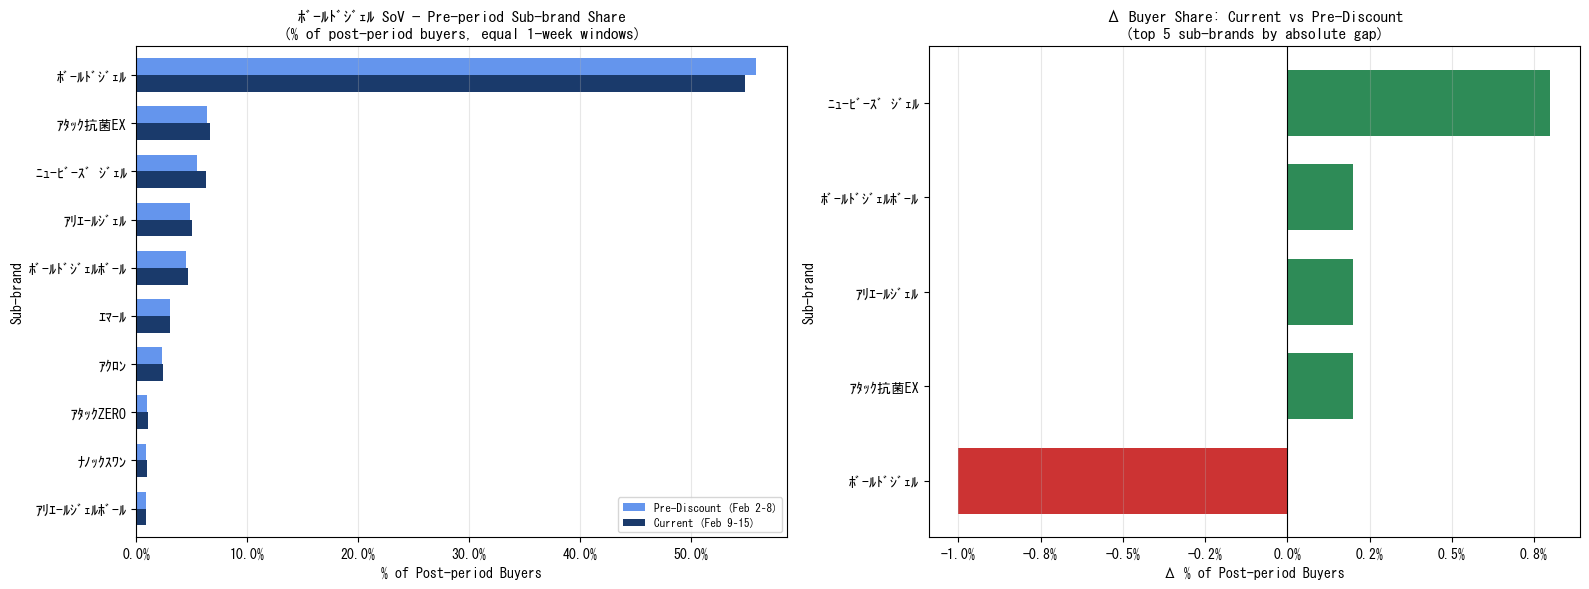

Chart saved: bold_gel_sov_1week_chart.png


In [16]:

top10_brands = (
    comparison_df[comparison_df['sub_brand'] != 'New to Category']
    .nlargest(10, 'pct_buyers_Current')['sub_brand']
    .tolist()
)
plot_df = comparison_df[comparison_df['sub_brand'].isin(top10_brands)].set_index('sub_brand')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: 2-period grouped bar (buyer share) — Pre-Discount vs Current
ax1 = axes[0]
cols_buyers = ['pct_buyers_Pre-Discount', 'pct_buyers_Current']
labels_p    = ['Pre-Discount (Feb 2–8)', 'Current (Feb 9–15)']
plot_df[cols_buyers].plot(
    kind='barh', ax=ax1, width=0.7,
    color=['#6495ed', '#1a3a6b']
)
ax1.set_title(
    f'{TARGET_SUB_BRAND} SoV — Pre-period Sub-brand Share\n'
    f'(% of post-period buyers, equal 1-week windows)', fontsize=11
)
ax1.set_xlabel('% of Post-period Buyers')
ax1.set_ylabel('Sub-brand')
ax1.legend(labels_p, loc='lower right', fontsize=8)
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Right: delta Current vs Pre-Discount — top 5 by absolute gap
ax2 = axes[1]
delta_df = (
    comparison_df[comparison_df['sub_brand'] != 'New to Category']
    [['sub_brand', 'Δ_buyers_vs_PreDiscount']]
    .set_index('sub_brand')
)
delta_df = (
    delta_df.reindex(delta_df['Δ_buyers_vs_PreDiscount'].abs().nlargest(5).index)
    .sort_values('Δ_buyers_vs_PreDiscount')
)
colors = ['#cc3333' if v < 0 else '#2e8b57' for v in delta_df['Δ_buyers_vs_PreDiscount']]
delta_df['Δ_buyers_vs_PreDiscount'].plot(kind='barh', ax=ax2, color=colors, width=0.7)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title(
    f'Δ Buyer Share: Current vs Pre-Discount\n'
    f'(top 5 sub-brands by absolute gap)', fontsize=11
)
ax2.set_xlabel('Δ % of Post-period Buyers')
ax2.set_ylabel('Sub-brand')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('bold_gel_sov_1week_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: bold_gel_sov_1week_chart.png')


---
## 10. Export Results to Excel

In [14]:
export_filename = f'bold_gel_sov_1week_{datetime.now().strftime("%Y%m%d")}.xlsx'

summary_rows = []
for period_name, dates in PERIODS.items():
    tpb = dq_results[period_name]['total_post_buyers']
    summary_rows.append({
        'Period'            : period_name,
        'Label'             : dates['label'],
        'Post Start'        : dates['post_start'],
        'Post End'          : dates['post_end'],
        'Pre Start'         : dates['pre_start'],
        'Pre End'           : dates['pre_end'],
        'Total Post Buyers' : tpb,
    })
df_summary = pd.DataFrame(summary_rows)

display_cols = [
    'brand', 'sub_brand',
    'SoV_ID', 'pct_of_post_buyers',
    'SoV_Value', 'pct_of_value', 'avg_value_per_buyer',
    'SoV_Unit', 'pct_of_units',
]

with pd.ExcelWriter(export_filename, engine='openpyxl') as writer:
    df_summary.to_excel(writer, sheet_name='Summary', index=False)
    for period_name in PERIODS:
        sov_tables[period_name][display_cols].to_excel(
            writer, sheet_name=f'{period_name}_SoV', index=False
        )
    comparison_df.to_excel(writer, sheet_name='Period_Comparison', index=False)

print(f'✅ Export complete: {export_filename}')
sheets = ['Summary'] + [f'{p}_SoV' for p in PERIODS] + ['Period_Comparison']
print(f'   Sheets: {", ".join(sheets)}')


✅ Export complete: bold_gel_sov_1week_20260219.xlsx
   Sheets: Summary, Current_SoV, Pre-Discount_SoV, Baseline_SoV, Period_Comparison
